<a href="https://colab.research.google.com/github/spoonylamp/spoonylamp/blob/main/dz4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Анализ чеков

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/cheque.csv', sep='\t')
df = df.drop(columns=['index', 'Unnamed: 0'], errors='ignore')
df['Дата продажи'] = pd.to_datetime(df['Дата продажи'])


In [ ]:
total_revenue = df['Сумма чека, руб.'].sum()
avg_check = df['Сумма чека, руб.'].mean()
avg_items = df['Кол-во товаров, ед.'].mean()
unique_customers = df['Имя'].nunique()

print(f"Общая выручка:      {total_revenue:,.0f} руб.")
print(f"средний чек:        {avg_check:,.0f} руб.")
print(f"Среднее кол-во товаров: {avg_items:.0f} ед.")
print(f"Уникальных клиентов: {unique_customers:,}")
print(f"Самый дорогой чек:  {df['Сумма чека, руб.'].max():,.0f} руб.")

Общая выручка:      9,998,523,362 руб.
средний чек:        99,985 руб.
Среднее кол-во товаров: 501 ед.
Уникальных клиентов: 99,538
Самый дорогой чек:  1,191,565 руб.


In [ ]:
top_clients = df.groupby('Имя')['Сумма чека, руб.'].sum().sort_values(ascending=False).head(5)
print("\n топ5 клиентов по выручке:")
for name, amount in top_clients.items():
    print(f"   {name[:25]:25} {amount:>12,.0f} руб.")


 топ5 клиентов по выручке:
   Елисеева Полина Афанасьев    1,191,565 руб.
   Семенова Любовь Наумовна     1,031,842 руб.
   Мария Руслановна Корнилов    1,022,705 руб.
   Фёкла Святославовна Колоб    1,019,401 руб.
   Соболева Зоя Эльдаровна      1,004,014 руб.


In [ ]:
df['Месяц'] = df['Дата продажи'].dt.strftime('%Y-%m')
monthly = df.groupby('Месяц')['Сумма чека, руб.'].sum()
best_month = monthly.idxmax()
print(f"\nСамый прибыльный месяц: {best_month} ({monthly.max()/1e6:.1f} млн руб.)")


Самый прибыльный месяц: 2025-08 (873.3 млн руб.)


In [ ]:
corr = df['Сумма чека, руб.'].corr(df['Кол-во товаров, ед.'])
print(f"\nКорреляция чек - кол-во товаров: {corr:.2f}")


🔗 Корреляция чек ↔ кол-во товаров: 0.00


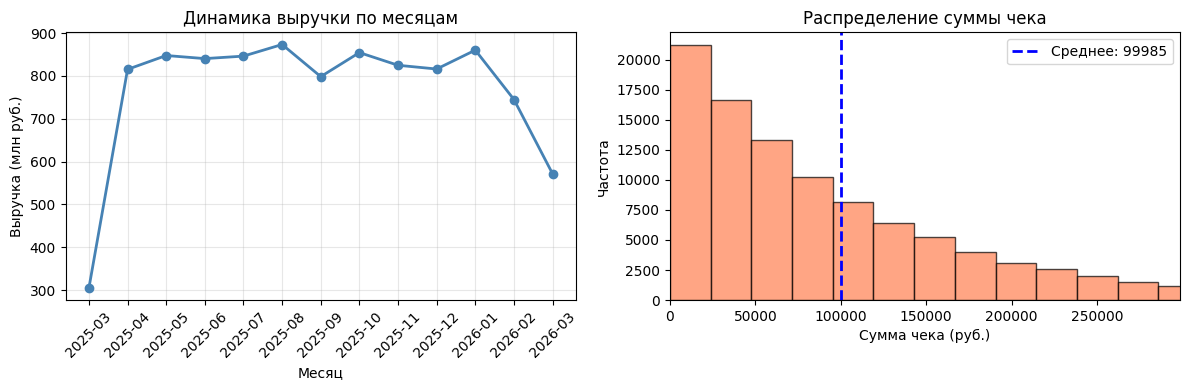

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(monthly.index, monthly.values/1e6, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Динамика выручки по месяцам', fontsize=12)
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Выручка (млн руб.)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Сумма чека, руб.'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(avg_check, color='blue', linestyle='--', linewidth=2, label=f'Среднее: {avg_check:.0f}')
axes[1].set_title('Распределение суммы чека', fontsize=12)
axes[1].set_xlabel('Сумма чека (руб.)')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].set_xlim([0, avg_check + 2*df['Сумма чека, руб.'].std()])

plt.tight_layout()
plt.show()


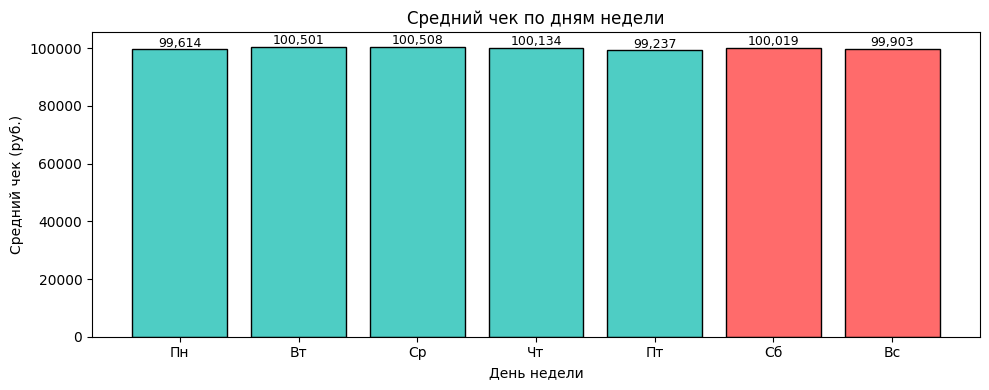

In [ ]:
plt.figure(figsize=(10, 4))
df['День недели'] = df['Дата продажи'].dt.day_name()
daily_avg = df.groupby('День недели')['Сумма чека, руб.'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
days_ru = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
colors = ['#4ecdc4']*5 + ['#ff6b6b']*2
plt.bar(days_ru, daily_avg.values, color=colors, edgecolor='black')
plt.title('Средний чек по дням недели', fontsize=12)
plt.xlabel('День недели')
plt.ylabel('Средний чек (руб.)')
for i, v in enumerate(daily_avg.values):
    plt.text(i, v + 1000, f'{v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**КЛЮЧЕВЫЕ ВЫВОДЫ**
- Магазин обслужил 99,538 уникальных клиентов
- Средний чек составляет 99,985 руб.
- Нет сильной связи между суммой чека и количеством товаров
- Лучший месяц для продаж — 2025-08
- Топ-5 клиентов приносят 0.1% всей выручки